## Example code for RTS,S and R21 vaccination

In [1]:
import sys
sys.path.append('..')
from Edinburgh_Model.model import *
from Edinburgh_Model.simulate_single_vaccine import *
from Edinburgh_Model.plot_matplotlib import *

### Efficacy of R21

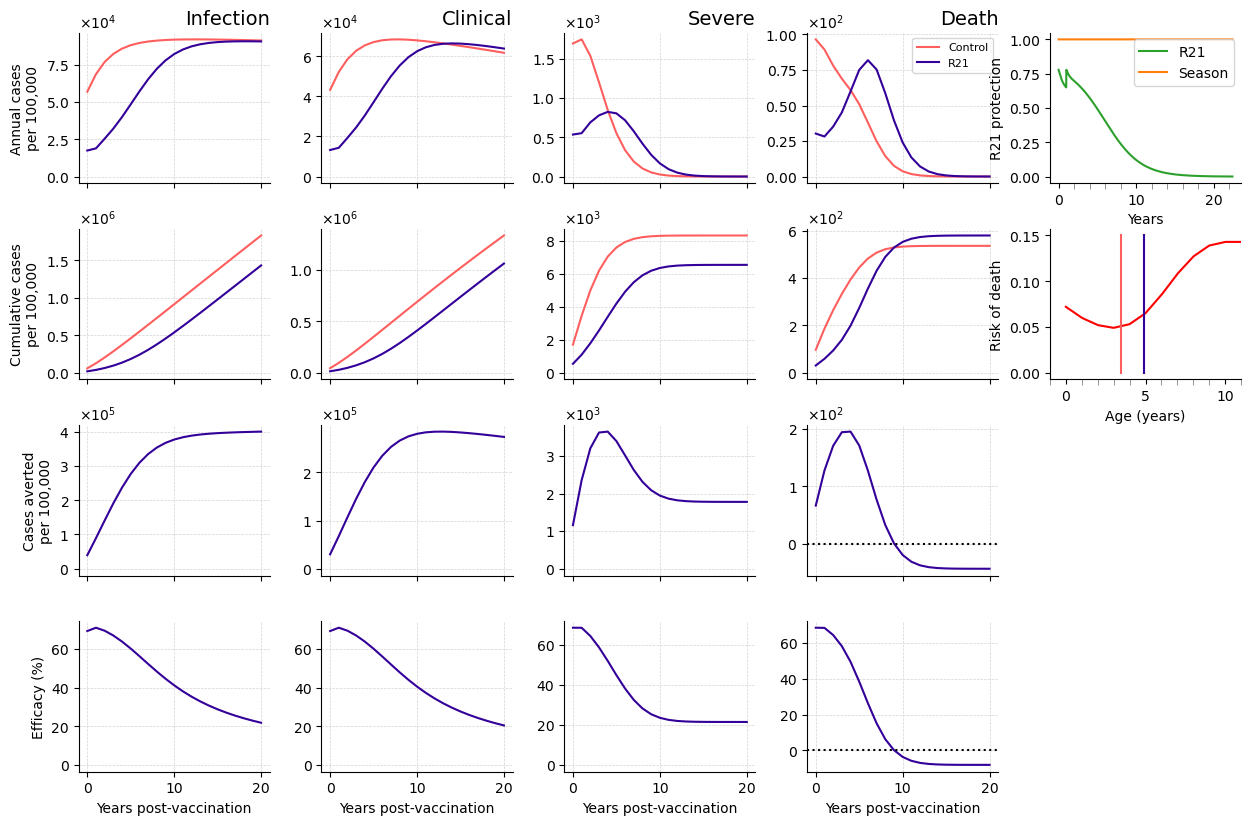

In [3]:
model = Model()

# set which variables to display
model.variables = Variables(['All infection', 'All clinical', 'Severe malaria', 'Direct deaths'])

# set which measures of each variable to display
model.measures = Measures(['cases', 'cdf', 'averted', 'efficacy'])

# set plot configuration parameters
model.Config(time_scale='Years', fig_xscale=1, fig_yscale=0.8, show_season=True, show_vac=True, show_smc=True, show_cfr=True)

# if plotting additional panels (eg vaccine protection or seasons) set panels_fn to populate panels
model.Sources(panels_fn=panels)

# set simulation model parameters, see ../Edinburgh_Model/model.py for parameter definitions
model.pars = Parameters(
    lsv=True,
    bsv=False,
    smc=False,
    popsize=100000,
    λ=1,
    β=0,
    children='cohort',
    study_months=21*12,
    season_peak=0,
    season_width=1,
    min_vac_age=int(5*weeks_per_month),
    vac_age_range=int(12*weeks_per_month),
    smc_offset=0,
    smc_repeats=4,
    nboosters_blood=1,
    nboosters_liver=1,
    protection_blood=False,
    recording='Last primary dose',
    control='Control',
    treatment='R21',
)

# simulate the model and return a pandas DataFrame with the results
sim1 = simulate_single_vaccine(model)

# plot the results with the cohort names
fig, axs = plot(model, ['Control', 'R21'], sim1)

### Compare RTS,S and R21

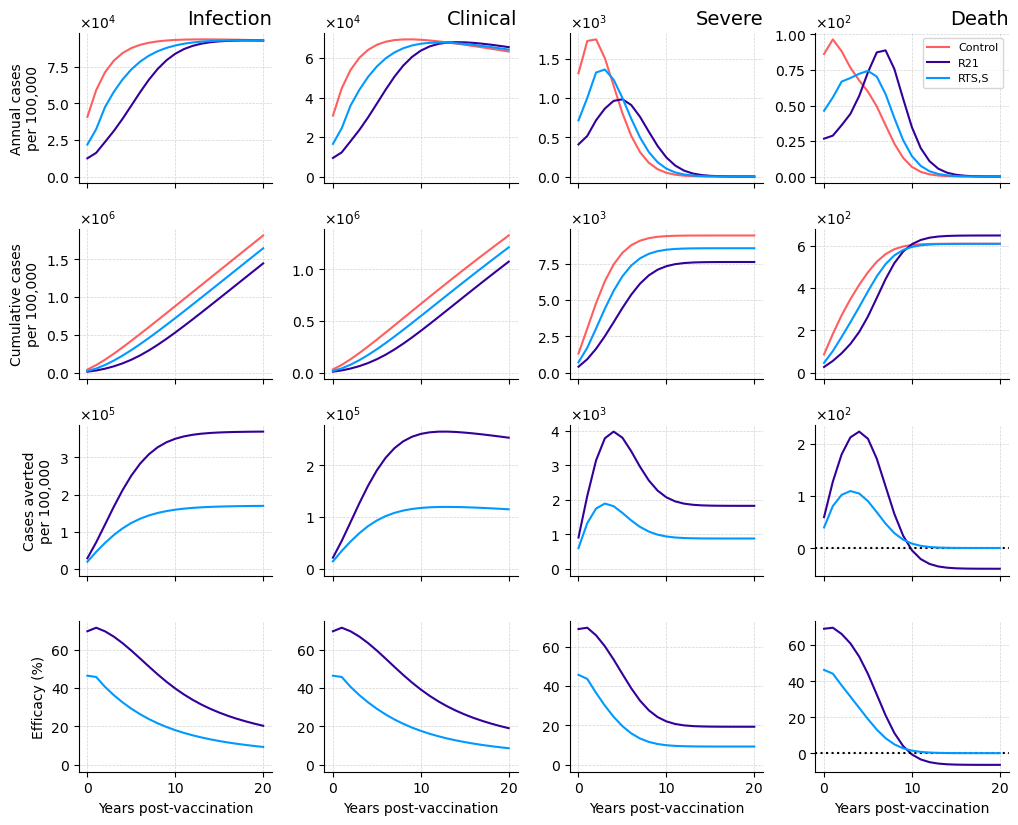

In [5]:
# We can use the same model defined above and just change the parameter "vac_profile_liver"
# and rename the treatment so that it is different from the previous simulation
model.pars.treatment = 'RTS,S'
# change the pre-erythrocytic vaccine profile to RTS,S and update the internal model parameters
model.pars.vac_profile_liver = 'Imperial RTS,S'
model.pars.update_pars('vac_profile_liver')

sim2 = simulate_single_vaccine(model)

# remove Control cohort form sim2 so that it is not plotted
sim2 = sim2.loc[:, ~sim2.columns.str.contains("Control")]
# merge the dataframes from the two simulations on column "ages"
both_sims = sim1.merge(sim2, on='ages')

# remove the panels as they cannot show two pre-erythrocytic vaccine profiles
model.Config(time_scale='Years', fig_xscale=1, fig_yscale=0.8, show_season=False, show_vac=False, show_smc=False, show_cfr=False)

fig, axs = plot(model, ['Control', 'R21', 'RTS,S'], both_sims)